# End-to-End Training Dataflow Audit (Masked Latent Index)

This notebook audits the complete training data flow with **exact config**:

`/home/wuhao/spectra-learning/configs/gems_a_masked_latent_index.py`

The audit is segmented by stages/modules:
1. Config and datamodule wiring
2. TFRecord parse stage (pre-augmentation)
3. Multicrop augmentation + masking invariants
4. Torch loader conversion path
5. Attention mask policy (`masked_query_to_unmasked_kv`)
6. Local->global token prediction path (latent remask + predictor + token SIGReg)
7. One non-compiled training step with optimizer/scheduler

**Important implementation notes reflected here**
- Global-view context is not masked at encoder input (`effective_masked_positions` zeros global rows).
- Local-to-global target is stop-grad (global token latent is detached in loss path).

All checks are executed on real data and produce explicit pass/fail summaries.


In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print("Project root:", ROOT)

Project root: /home/wuhao/spectra-learning


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from ml_collections import config_dict

from utils.training import load_config, build_model_from_config
from input_pipeline import TfLightningDataModule, _build_dataset, numpy_batch_to_torch
from networks.transformer_torch import build_masked_attention_allow_matrix
from train import _build_optimizers, _resolve_autocast_dtype, _train_step_impl

In [3]:
CONFIG_PATH = Path("/home/wuhao/spectra-learning/configs/gems_a_masked_latent_index.py")
cfg = load_config(CONFIG_PATH)

print("Config path:", CONFIG_PATH)
print("dataset:", cfg.dataset)
print("batch_size:", cfg.batch_size)
print("num_views:", 1 + cfg.multicrop_num_local_views)
print("use_masked_token_input:", cfg.use_masked_token_input)
print("masked_token_position_mode:", cfg.masked_token_position_mode)
print("masked_token_attention_mode:", cfg.masked_token_attention_mode)
print("masked_token_loss_weight:", cfg.masked_token_loss_weight)
print("global_view_policy:", "full-spectrum target")

Config path: /home/wuhao/spectra-learning/configs/gems_a_masked_latent_index.py
dataset: gems_a
batch_size: 256
num_views: 5
use_masked_token_input: True
masked_token_position_mode: index
masked_token_attention_mode: masked_query_to_unmasked_kv
masked_token_loss_weight: 1.0
global_view_policy: full-spectrum target


In [4]:
dm = TfLightningDataModule(cfg, seed=int(cfg.seed))

print("DataModule info:")
for k, v in dm.info.items():
    print(f"  {k}: {v}")

print("\nStep counts:")
for k, v in dm.steps.items():
    print(f"  {k}: {v}")

DataModule info:
  tfrecord_dir: /home/wuhao/spectra-learning/data/gems_peaklist_tfrecord
  train_size: 39854312
  validation_size: 2097596
  massspec_train_size: 194119
  massspec_val_size: 19429
  massspec_test_size: 17556
  massspec_metadata_version: 3
  massspec_adduct_vocab: {'unknown': 0, '[M+H]+': 1, '[M+Na]+': 2}
  massspec_instrument_type_vocab: {'unknown': 0, 'Orbitrap': 1, 'QTOF': 2}
  massspec_adduct_vocab_size: 3
  massspec_instrument_type_vocab_size: 3
  num_peaks: 60
  fingerprint_bits: 1024
  max_precursor_mz: 1000.0
  peak_mz_min: 20.0
  peak_mz_max: 1000.0

Step counts:
  gems_train: 155680
  gems_val: 8194
  gems_test: 8194
  massspec_train: 758
  massspec_val: 76
  massspec_test: 69


## Stage 1: TFRecord Parse (Pre-Augmentation)

**What this stage shows**
- Raw parsed peak tensors before multicrop/masking logic.
- Diagram: `fig_dataflow_stage1_raw_parse.png`.

**How to read the diagram**
- Left: valid peaks in spectral space (`m/z` vs intensity).
- Right: slot view (green valid, red padded) to verify slot occupancy and padding layout.


In [5]:
raw_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=16,
    shuffle_buffer=10_000,
    seed=int(cfg.seed),
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    augmentation_type="none",
    peak_ordering=cfg.peak_ordering,
)
raw_batch = next(raw_ds.as_numpy_iterator())

print("Raw keys:", sorted(raw_batch.keys()))
for k, v in raw_batch.items():
    if hasattr(v, "shape"):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

Raw keys: ['intensity', 'mz', 'peak_intensity', 'peak_mz', 'peak_valid_mask', 'precursor_mz', 'rt']
  peak_mz: shape=(16, 60), dtype=float32
  peak_intensity: shape=(16, 60), dtype=float32
  peak_valid_mask: shape=(16, 60), dtype=bool
  precursor_mz: shape=(16,), dtype=float32
  rt: shape=(16,), dtype=float32
  mz: shape=(16, 60), dtype=float32
  intensity: shape=(16, 60), dtype=float32


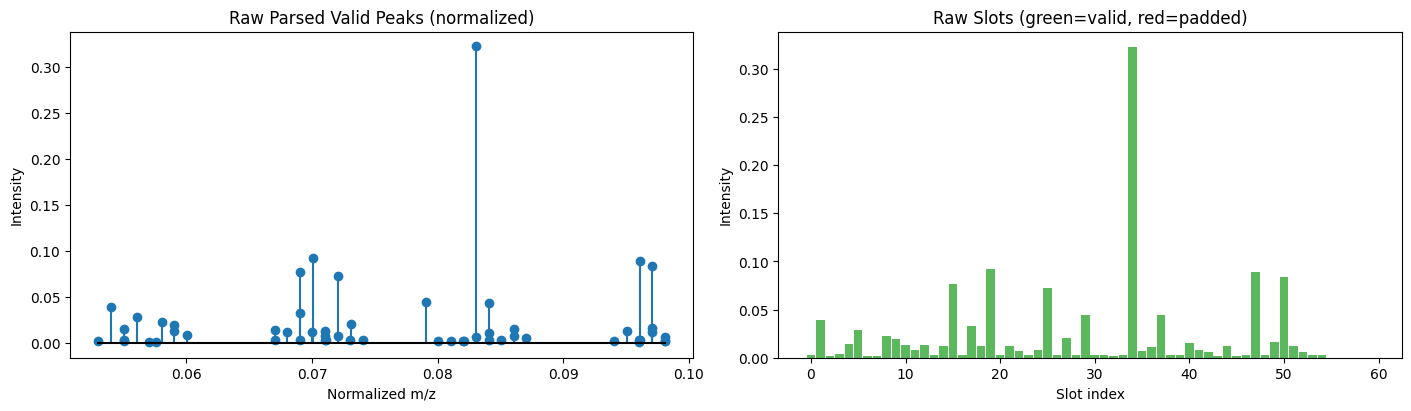

In [6]:
idx = 0
mz = raw_batch["peak_mz"][idx]
intensity = raw_batch["peak_intensity"][idx]
valid = raw_batch["peak_valid_mask"][idx].astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

axes[0].stem(mz[valid], intensity[valid], linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[0].set_title("Raw Parsed Valid Peaks (normalized)")
axes[0].set_xlabel("Normalized m/z")
axes[0].set_ylabel("Intensity")

slot = np.arange(len(valid))
slot_color = np.where(valid, "#5cb85c", "#d9534f")
axes[1].bar(slot, intensity, color=slot_color, width=0.9)
axes[1].set_title("Raw Slots (green=valid, red=padded)")
axes[1].set_xlabel("Slot index")
axes[1].set_ylabel("Intensity")

plt.savefig("notebooks/fig_dataflow_stage1_raw_parse.png", bbox_inches="tight")
plt.show()

## Stage 2: Augmented Batch -> Torch Conversion (Training-Equivalent)

**What this stage shows**
- Exact `fused_*` tensors consumed by `forward_augmented`.
- Diagrams: `fig_dataflow_stage2_masks_and_views.png`, `fig_dataflow_stage2_sample_trace.png`.

**How to read the diagrams**
- `fig_dataflow_stage2_masks_and_views.png`: global mask heatmaps + per-view masked fraction.
- `fig_dataflow_stage2_sample_trace.png`: one sample across all views (`view x slot`) for
  `fused_mz`, `fused_intensity`, `valid`, `masked`. This is the canonical slot-level input trace.


In [7]:
aug_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=int(cfg.batch_size),
    shuffle_buffer=int(cfg.shuffle_buffer),
    seed=int(cfg.seed),
    drop_remainder=bool(cfg.drop_remainder),
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    augmentation_type="multicrop",
    multicrop_num_local_views=int(cfg.multicrop_num_local_views),
    multicrop_local_keep_fraction=float(cfg.multicrop_local_keep_fraction),
    mz_jitter_std=float(cfg.sigreg_mz_jitter_std),
    intensity_jitter_std=float(cfg.sigreg_intensity_jitter_std),
    peak_ordering=cfg.peak_ordering,
)
aug_batch_np = next(aug_ds.as_numpy_iterator())
train_batch = numpy_batch_to_torch(aug_batch_np)

print("Train-equivalent batch keys:", sorted(train_batch.keys()))
for k, v in train_batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: shape={tuple(v.shape)}, dtype={v.dtype}, device={v.device}")
    else:
        print(f"  {k}: type={type(v)}")

Train-equivalent batch keys: ['fused_intensity', 'fused_masked_positions', 'fused_mz', 'fused_padding_mask', 'fused_precursor_mz', 'fused_valid_mask', 'intensity', 'mz', 'peak_intensity', 'peak_mz', 'peak_padding_mask', 'peak_valid_mask', 'precursor_mz', 'rt']
  peak_mz: shape=(256, 60), dtype=torch.float32, device=cpu
  peak_intensity: shape=(256, 60), dtype=torch.float32, device=cpu
  peak_valid_mask: shape=(256, 60), dtype=torch.bool, device=cpu
  precursor_mz: shape=(256,), dtype=torch.float32, device=cpu
  rt: shape=(256,), dtype=torch.float32, device=cpu
  mz: shape=(256, 60), dtype=torch.float32, device=cpu
  intensity: shape=(256, 60), dtype=torch.float32, device=cpu
  fused_mz: shape=(1280, 60), dtype=torch.float32, device=cpu
  fused_intensity: shape=(1280, 60), dtype=torch.float32, device=cpu
  fused_precursor_mz: shape=(1280,), dtype=torch.float32, device=cpu
  fused_valid_mask: shape=(1280, 60), dtype=torch.bool, device=cpu
  fused_masked_positions: shape=(1280, 60), dtype

In [8]:
tb = {
    k: (v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else v)
    for k, v in train_batch.items()
}

fused_valid = tb["fused_valid_mask"].astype(bool)
fused_masked = tb["fused_masked_positions"].astype(bool)
fused_intensity = tb["fused_intensity"]
V = int(1 + cfg.multicrop_num_local_views)
B = fused_valid.shape[0] // V

checks = {}
checks["masked_subset_of_valid"] = bool(np.all((~fused_masked) | fused_valid))
checks["masked_positions_not_compacted"] = bool(
    np.any((~fused_masked[:, :-1]) & fused_masked[:, 1:])
)
checks["masked_positions_present"] = bool(fused_masked.any())
checks["masked_intensity_retained_nonzero_fraction"] = float(
    (fused_intensity[fused_masked] > 0.0).mean()
)
checks["global_masked_fraction"] = float(fused_masked[: 1 * B].mean())
checks["local_masked_fraction"] = float(fused_masked[1 * B :].mean())

for k, v in checks.items():
    print(f"{k}: {v}")

masked_subset_of_valid: True
masked_positions_not_compacted: True
masked_positions_present: True
masked_intensity_retained_nonzero_fraction: 0.9985457764289327
global_masked_fraction: 0.0
local_masked_fraction: 0.51484375


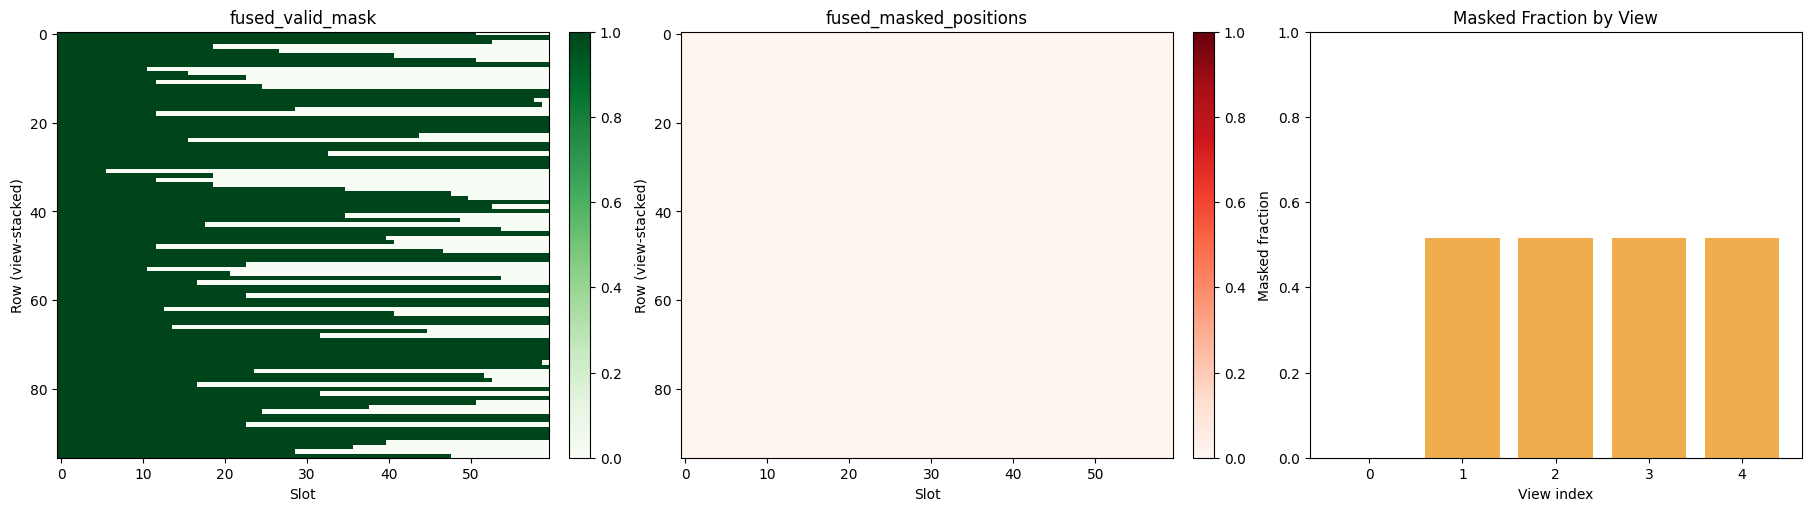

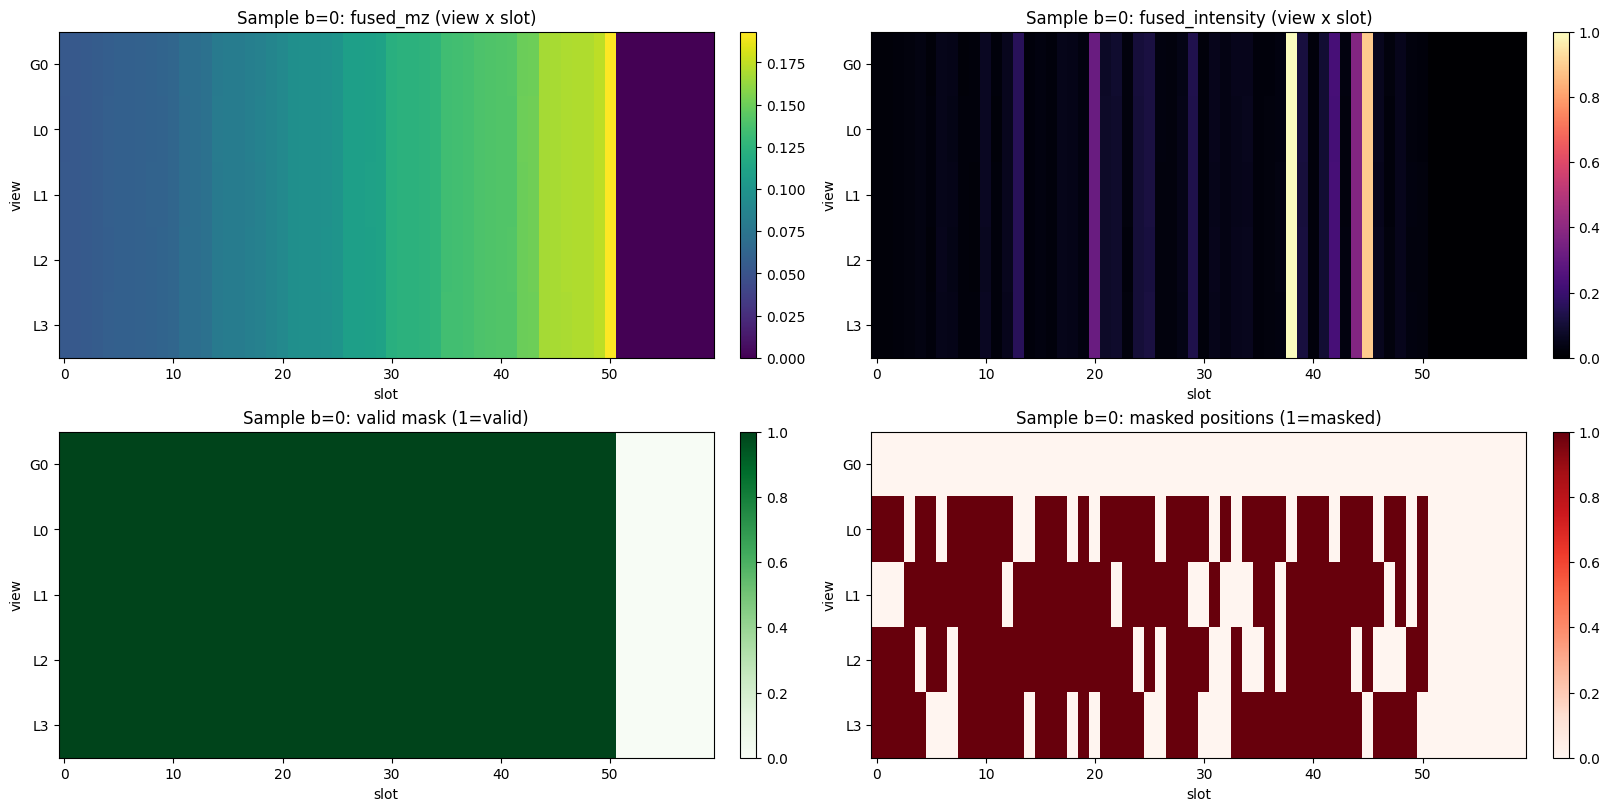

sample_b: 0
view_rows: [0, 256, 512, 768, 1024]


In [9]:
rows_to_show = min(96, fused_valid.shape[0])
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].imshow(
    fused_valid[:rows_to_show].astype(float),
    aspect="auto",
    cmap="Greens",
    vmin=0,
    vmax=1,
)
axes[0].set_title("fused_valid_mask")
axes[0].set_xlabel("Slot")
axes[0].set_ylabel("Row (view-stacked)")

im1 = axes[1].imshow(
    fused_masked[:rows_to_show].astype(float),
    aspect="auto",
    cmap="Reds",
    vmin=0,
    vmax=1,
)
axes[1].set_title("fused_masked_positions")
axes[1].set_xlabel("Slot")
axes[1].set_ylabel("Row (view-stacked)")

view_mask_frac = []
for v in range(V):
    view_rows = fused_masked[v * B : (v + 1) * B]
    view_mask_frac.append(view_rows.mean())
axes[2].bar(
    np.arange(V),
    view_mask_frac,
    color=["#5cb85c"] * int(1) + ["#f0ad4e"] * int(cfg.multicrop_num_local_views),
)
axes[2].set_title("Masked Fraction by View")
axes[2].set_xlabel("View index")
axes[2].set_ylabel("Masked fraction")
axes[2].set_ylim(0, 1)

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.savefig("notebooks/fig_dataflow_stage2_masks_and_views.png", bbox_inches="tight")
plt.show()

# --- Extra visualization: per-sample view-stacked trace (data in + masking) ---
sample_b = 0
view_rows = [v * B + sample_b for v in range(V)]
sample_mz = tb["fused_mz"][view_rows]
sample_intensity = tb["fused_intensity"][view_rows]
sample_valid = fused_valid[view_rows]
sample_masked = fused_masked[view_rows]

fig, axes = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)

im_a = axes[0, 0].imshow(sample_mz, aspect="auto", cmap="viridis")
axes[0, 0].set_title("Sample b=0: fused_mz (view x slot)")
axes[0, 0].set_xlabel("slot")
axes[0, 0].set_ylabel("view")
fig.colorbar(im_a, ax=axes[0, 0], fraction=0.046, pad=0.04)

im_b = axes[0, 1].imshow(sample_intensity, aspect="auto", cmap="magma")
axes[0, 1].set_title("Sample b=0: fused_intensity (view x slot)")
axes[0, 1].set_xlabel("slot")
axes[0, 1].set_ylabel("view")
fig.colorbar(im_b, ax=axes[0, 1], fraction=0.046, pad=0.04)

im_c = axes[1, 0].imshow(
    sample_valid.astype(float), aspect="auto", cmap="Greens", vmin=0, vmax=1
)
axes[1, 0].set_title("Sample b=0: valid mask (1=valid)")
axes[1, 0].set_xlabel("slot")
axes[1, 0].set_ylabel("view")
fig.colorbar(im_c, ax=axes[1, 0], fraction=0.046, pad=0.04)

im_d = axes[1, 1].imshow(
    sample_masked.astype(float), aspect="auto", cmap="Reds", vmin=0, vmax=1
)
axes[1, 1].set_title("Sample b=0: masked positions (1=masked)")
axes[1, 1].set_xlabel("slot")
axes[1, 1].set_ylabel("view")
fig.colorbar(im_d, ax=axes[1, 1], fraction=0.046, pad=0.04)

for ax in axes.reshape(-1):
    ax.set_yticks(np.arange(V))
    ax.set_yticklabels([f"G{v}" if v < int(1) else f"L{v - int(1)}" for v in range(V)])

plt.savefig("notebooks/fig_dataflow_stage2_sample_trace.png", bbox_inches="tight")
plt.show()

print("sample_b:", sample_b)
print("view_rows:", view_rows)

## Stage 3: Attention Policy Audit (`masked_query_to_unmasked_kv`)

**What this stage shows**
- Binary attention reachability for selected rows under configured masking policy.
- Diagrams: `fig_dataflow_stage3_attention_policy.png`,
  `fig_dataflow_stage3_global_local_attention_reachability.png`.

**How to read the diagrams**
- `*_attention_policy`: direct matrix comparison (padding-only vs configured vs removed edges).
- `*_global_local_attention_reachability`: compare one global row and one local row, including
  per-query attendable-key counts so you can see exactly which query positions can attend where.


In [10]:
candidate_rows = np.where(fused_masked.any(axis=1))[0]
row = int(candidate_rows[0])
valid = fused_valid[row]
masked = fused_masked[row]

padding_allow = np.logical_and(valid[:, None], valid[None, :])
variant_allow = (
    build_masked_attention_allow_matrix(
        torch.from_numpy(valid[None, :]),
        torch.from_numpy(masked[None, :]),
    )[0]
    .cpu()
    .numpy()
)
blocked_edges = np.logical_and(padding_allow, ~variant_allow)

expected_block = np.logical_and(
    np.logical_and((~masked)[:, None], masked[None, :]),
    padding_allow,
)

print("selected fused row:", row)
print("valid count:", int(valid.sum()))
print("masked count:", int(masked.sum()))
print(
    "blocked pattern matches expected:",
    bool(np.array_equal(blocked_edges, expected_block)),
)

selected fused row: 256
valid count: 51
masked count: 38
blocked pattern matches expected: True


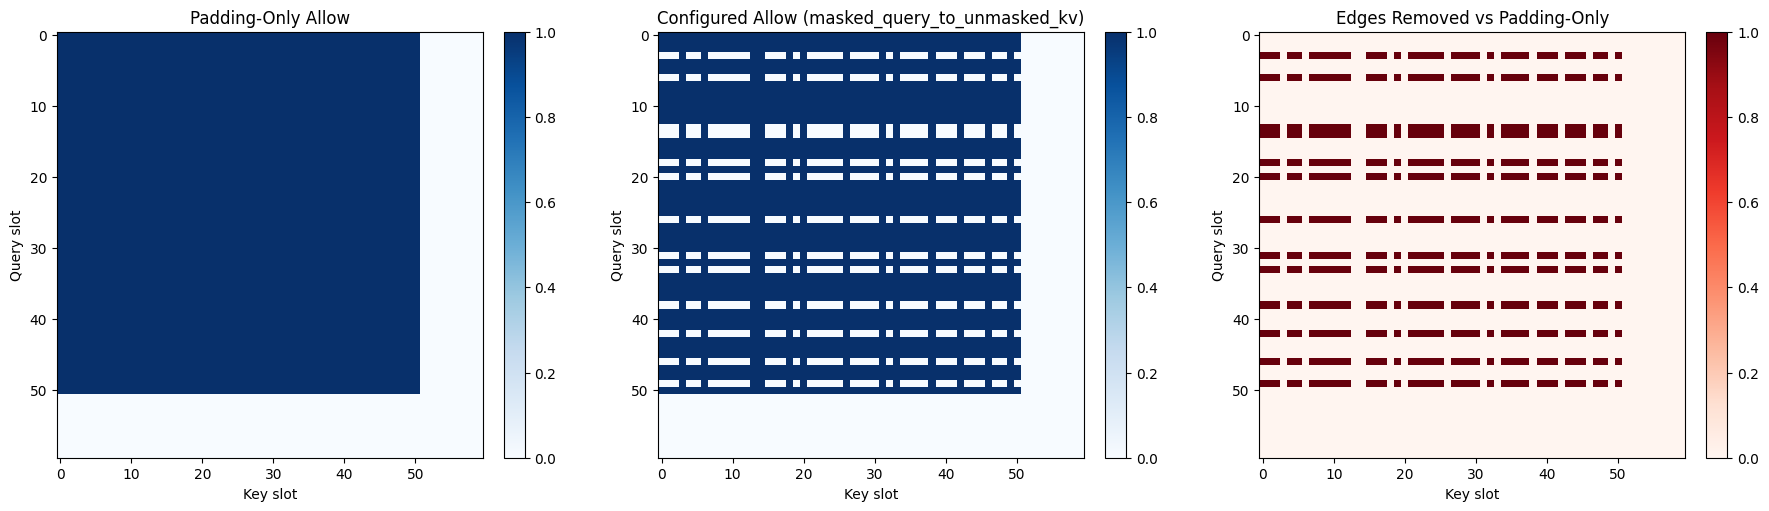

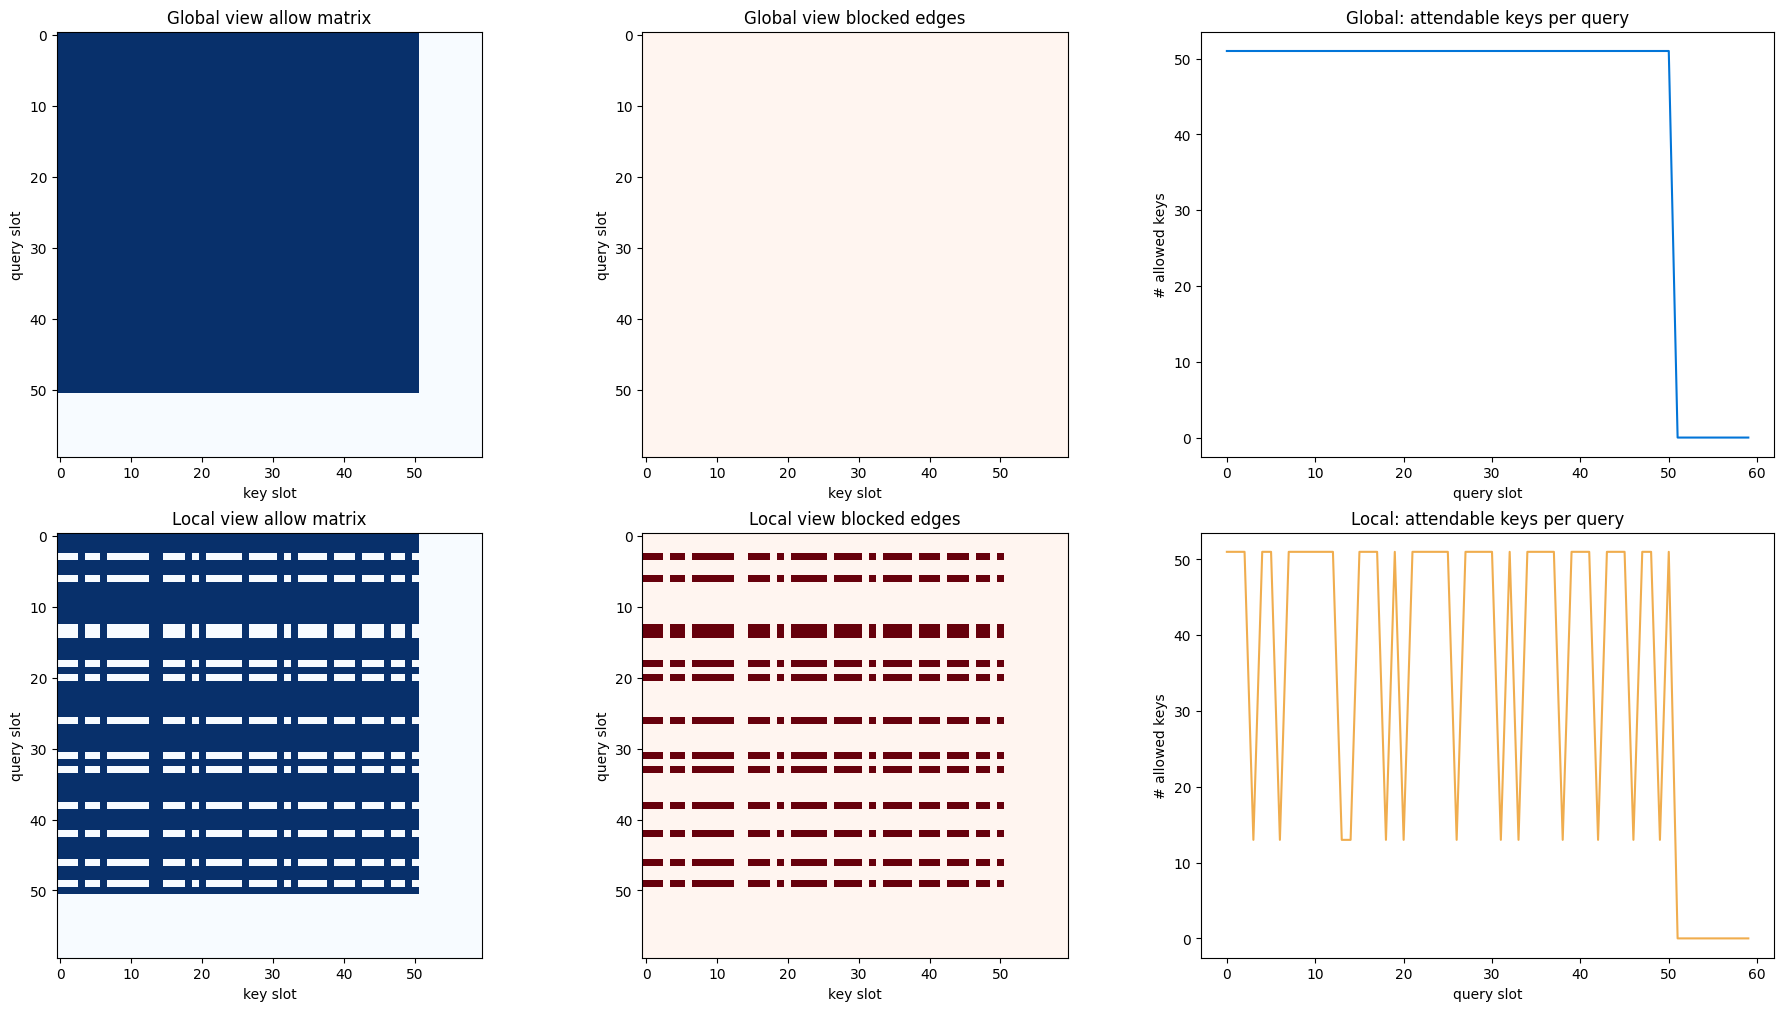

global_row_idx: 0 | local_row_idx: 256
global masked count: 0 | local masked count: 38


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].imshow(padding_allow.astype(float), vmin=0, vmax=1, cmap="Blues")
axes[0].set_title("Padding-Only Allow")
axes[0].set_xlabel("Key slot")
axes[0].set_ylabel("Query slot")

im1 = axes[1].imshow(variant_allow.astype(float), vmin=0, vmax=1, cmap="Blues")
axes[1].set_title("Configured Allow (masked_query_to_unmasked_kv)")
axes[1].set_xlabel("Key slot")
axes[1].set_ylabel("Query slot")

im2 = axes[2].imshow(blocked_edges.astype(float), vmin=0, vmax=1, cmap="Reds")
axes[2].set_title("Edges Removed vs Padding-Only")
axes[2].set_xlabel("Key slot")
axes[2].set_ylabel("Query slot")

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.savefig("notebooks/fig_dataflow_stage3_attention_policy.png", bbox_inches="tight")
plt.show()

# --- Extra visualization: global vs local attention reachability by position ---
sample_b = 0
global_row_idx = sample_b
local_row_idx = int(1) * B + sample_b


def _build_attention_maps_for_row(row_idx: int):
    v = fused_valid[row_idx]
    m = fused_masked[row_idx]
    padding_allow_map = np.logical_and(v[:, None], v[None, :])
    allow_map = (
        build_masked_attention_allow_matrix(
            torch.from_numpy(v[None, :]),
            torch.from_numpy(m[None, :]),
        )[0]
        .cpu()
        .numpy()
    )
    blocked_map = np.logical_and(padding_allow_map, ~allow_map)
    return v, m, padding_allow_map, allow_map, blocked_map


g_v, g_m, g_pad, g_allow, g_blocked = _build_attention_maps_for_row(global_row_idx)
l_v, l_m, l_pad, l_allow, l_blocked = _build_attention_maps_for_row(local_row_idx)

g_query_degree = g_allow.sum(axis=1)
l_query_degree = l_allow.sum(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

axes[0, 0].imshow(g_allow.astype(float), vmin=0, vmax=1, cmap="Blues")
axes[0, 0].set_title("Global view allow matrix")
axes[0, 0].set_xlabel("key slot")
axes[0, 0].set_ylabel("query slot")

axes[0, 1].imshow(g_blocked.astype(float), vmin=0, vmax=1, cmap="Reds")
axes[0, 1].set_title("Global view blocked edges")
axes[0, 1].set_xlabel("key slot")
axes[0, 1].set_ylabel("query slot")

axes[0, 2].plot(np.arange(len(g_query_degree)), g_query_degree, color="#0275d8")
axes[0, 2].set_title("Global: attendable keys per query")
axes[0, 2].set_xlabel("query slot")
axes[0, 2].set_ylabel("# allowed keys")

axes[1, 0].imshow(l_allow.astype(float), vmin=0, vmax=1, cmap="Blues")
axes[1, 0].set_title("Local view allow matrix")
axes[1, 0].set_xlabel("key slot")
axes[1, 0].set_ylabel("query slot")

axes[1, 1].imshow(l_blocked.astype(float), vmin=0, vmax=1, cmap="Reds")
axes[1, 1].set_title("Local view blocked edges")
axes[1, 1].set_xlabel("key slot")
axes[1, 1].set_ylabel("query slot")

axes[1, 2].plot(np.arange(len(l_query_degree)), l_query_degree, color="#f0ad4e")
axes[1, 2].set_title("Local: attendable keys per query")
axes[1, 2].set_xlabel("query slot")
axes[1, 2].set_ylabel("# allowed keys")

plt.savefig(
    "notebooks/fig_dataflow_stage3_global_local_attention_reachability.png",
    bbox_inches="tight",
)
plt.show()

print("global_row_idx:", global_row_idx, "| local_row_idx:", local_row_idx)
print("global masked count:", int(g_m.sum()), "| local masked count:", int(l_m.sum()))

## Stage 4: Model Forward Dissection (Local->Global Token Prediction, No `torch.compile`)

**What this stage shows**
- Encoder input masking with global rows force-unmasked (`effective_masked_positions`).
- Token latent extraction per view and slot.
- Local latent remask, predictor output, stop-grad global target, per-slot L1 contributions.
- Token-level SIGReg and total-loss reconstruction.
- Diagrams: `fig_dataflow_stage4_local_global_l1.png`,
  `fig_dataflow_stage4_slot_correspondence_loss.png`,
  `fig_dataflow_stage4_local_views_slot_loss_heatmap.png`.

**How to read the diagrams**
- `local_global_l1`: masked-vs-unmasked token L1 distribution.
- `slot_correspondence_loss`: explicit slot mapping local->global->mask->loss contribution.
- `local_views_slot_loss_heatmap`: how each local view contributes per slot.


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = build_model_from_config(cfg).to(device)
model.eval()

cfg_bidir = config_dict.ConfigDict(cfg.to_dict())
cfg_bidir.masked_token_attention_mode = "bidirectional"
model_bidir = build_model_from_config(cfg_bidir).to(device)
model_bidir.load_state_dict(model.state_dict(), strict=True)
model_bidir.eval()

print("model attention mode (iso):", model.encoder.masked_token_attention_mode)
print("model attention mode (bidir):", model_bidir.encoder.masked_token_attention_mode)

device: cuda


model attention mode (iso): masked_query_to_unmasked_kv
model attention mode (bidir): bidirectional


In [13]:
rows = model.num_views * 8  # keep view structure intact
small_batch = {}
for k, v in train_batch.items():
    if isinstance(v, torch.Tensor) and v.ndim > 0 and k.startswith("fused_"):
        small_batch[k] = v[:rows].to(device)
    elif isinstance(v, torch.Tensor):
        small_batch[k] = v.to(device)
    else:
        small_batch[k] = v

fused_mz_t = small_batch["fused_mz"]
fused_intensity_t = small_batch["fused_intensity"]
fused_valid_t = small_batch["fused_valid_mask"]
fused_prec_t = small_batch["fused_precursor_mz"]
fused_masked_t = small_batch["fused_masked_positions"] & fused_valid_t

V = model.num_views
N = fused_masked_t.shape[1]

# Match model implementation exactly: never mask global-view encoder context.
effective_masked_t = fused_masked_t.reshape(V, -1, N).clone()
effective_masked_t[:1] = False
effective_masked_t = effective_masked_t.reshape_as(fused_masked_t)

student_intensity_t = fused_intensity_t.masked_fill(effective_masked_t, 0.0)

with torch.no_grad():
    fused_emb = model.encoder(
        fused_mz_t,
        student_intensity_t,
        valid_mask=fused_valid_t,
        precursor_mz=fused_prec_t,
        masked_positions=effective_masked_t,
        mask_token=model.mask_token,
    )

    B = fused_emb.shape[0] // V
    D = fused_emb.shape[2]

    token_emb = fused_emb.reshape(V, B, N, D)
    token_valid = fused_valid_t.reshape(V, B, N)
    token_masked = effective_masked_t.reshape(V, B, N)

    # Match model implementation exactly: stop-grad on global target branch.
    global_token_emb = token_emb[0].detach()
    latent_mask_token = model.latent_mask_token.view(1, 1, -1).to(
        dtype=fused_emb.dtype,
        device=fused_emb.device,
    )

    l1_num = torch.zeros((), dtype=fused_emb.dtype, device=fused_emb.device)
    l1_den = torch.zeros((), dtype=fused_emb.dtype, device=fused_emb.device)
    l1_num_masked_only = torch.zeros((), dtype=fused_emb.dtype, device=fused_emb.device)
    l1_den_masked_only = torch.zeros((), dtype=fused_emb.dtype, device=fused_emb.device)
    per_token_l1_by_local_view = []

    for local_view_idx in range(1, model.num_views):
        local_token_emb = token_emb[local_view_idx]
        local_valid = token_valid[local_view_idx]
        local_mask = token_masked[local_view_idx]

        local_token_emb_remasked = torch.where(
            local_mask.unsqueeze(-1),
            latent_mask_token,
            local_token_emb,
        )
        local_token_pred = model.masked_latent_predictor(local_token_emb_remasked)
        per_token_l1 = (local_token_pred - global_token_emb).abs().mean(dim=-1)
        per_token_l1_by_local_view.append(per_token_l1)

        local_valid_float = local_valid.float()
        local_mask_float = local_mask.float()
        l1_num = l1_num + (per_token_l1 * local_valid_float).sum()
        l1_den = l1_den + local_valid_float.sum()
        l1_num_masked_only = (
            l1_num_masked_only + (per_token_l1 * local_mask_float).sum()
        )
        l1_den_masked_only = l1_den_masked_only + local_mask_float.sum()

    manual_local_global_l1_loss = l1_num / l1_den.clamp_min(1.0)
    manual_local_global_l1_masked_only = (
        l1_num_masked_only / l1_den_masked_only.clamp_min(1.0)
    )

    # Seed-match SIGReg random projections for strict manual-vs-model parity.
    torch.manual_seed(2026)
    manual_token_sigreg_loss = model.sigreg(fused_emb[fused_valid_t])
    manual_total_loss = (
        model.masked_token_loss_weight * manual_local_global_l1_loss
        + model.sigreg_lambda * manual_token_sigreg_loss
    )

    torch.manual_seed(2026)
    metrics = model.forward_augmented(small_batch)

print("manual local_global_l1_loss:", float(manual_local_global_l1_loss))
print("model  local_global_l1_loss:", float(metrics["local_global_l1_loss"]))
print(
    "abs diff local_global_l1_loss:",
    float((manual_local_global_l1_loss - metrics["local_global_l1_loss"]).abs()),
)

print("manual token_sigreg_loss:", float(manual_token_sigreg_loss))
print("model  token_sigreg_loss:", float(metrics["token_sigreg_loss"]))
print(
    "abs diff token_sigreg_loss:",
    float((manual_token_sigreg_loss - metrics["token_sigreg_loss"]).abs()),
)

print("manual total loss:", float(manual_total_loss))
print("model  total loss:", float(metrics["loss"]))
print("abs diff total loss:", float((manual_total_loss - metrics["loss"]).abs()))

print("all-valid local->global L1:", float(manual_local_global_l1_loss))
print("masked-only local->global L1:", float(manual_local_global_l1_masked_only))
print(
    "difference (all-valid - masked-only):",
    float((manual_local_global_l1_loss - manual_local_global_l1_masked_only).abs()),
)

print("masked slots in small batch (raw):", int(fused_masked_t.sum().item()))
print("masked slots in small batch (effective):", int(effective_masked_t.sum().item()))
print("valid slots in small batch:", int(fused_valid_t.sum().item()))

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


manual local_global_l1_loss: 0.6687847971916199
model  local_global_l1_loss: 0.6687847971916199
abs diff local_global_l1_loss: 0.0
manual token_sigreg_loss: 1692.9017333984375
model  token_sigreg_loss: 1692.9017333984375
abs diff token_sigreg_loss: 0.0
manual total loss: 169.95895385742188
model  total loss: 169.95895385742188
abs diff total loss: 0.0
all-valid local->global L1: 0.6687847971916199
masked-only local->global L1: 0.0
difference (all-valid - masked-only): 0.6687847971916199
masked slots in small batch (raw): 0
masked slots in small batch (effective): 0
valid slots in small batch: 1662


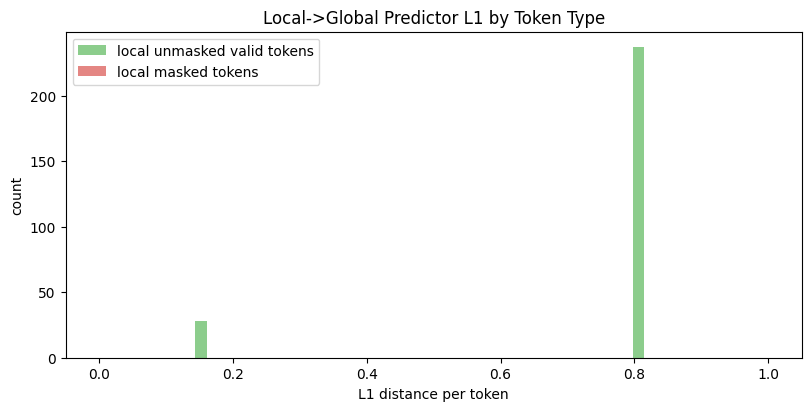

/tmp/ipykernel_2828235/457432478.py:22: RuntimeWarning: Mean of empty slice.
  print('mean L1 (masked local tokens):', float(masked_l1.mean()))
/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


mean L1 (masked local tokens): nan
mean L1 (unmasked local tokens): 0.7375462055206299
Slot correspondence table (sample_b=0, first local view):
 slot  global_valid  local_valid  local_masked  latent_remasked  token_l1_local_to_global  loss_contribution  loss_contribution_pct
    0          True         True         False            False                  0.814581           0.814581               0.090906
    1          True         True         False            False                  0.814797           0.814797               0.090930
    2          True         True         False            False                  0.814775           0.814775               0.090928
    3          True         True         False            False                  0.814655           0.814655               0.090914
    4          True         True         False            False                  0.813989           0.813989               0.090840
    5          True         True         False            False

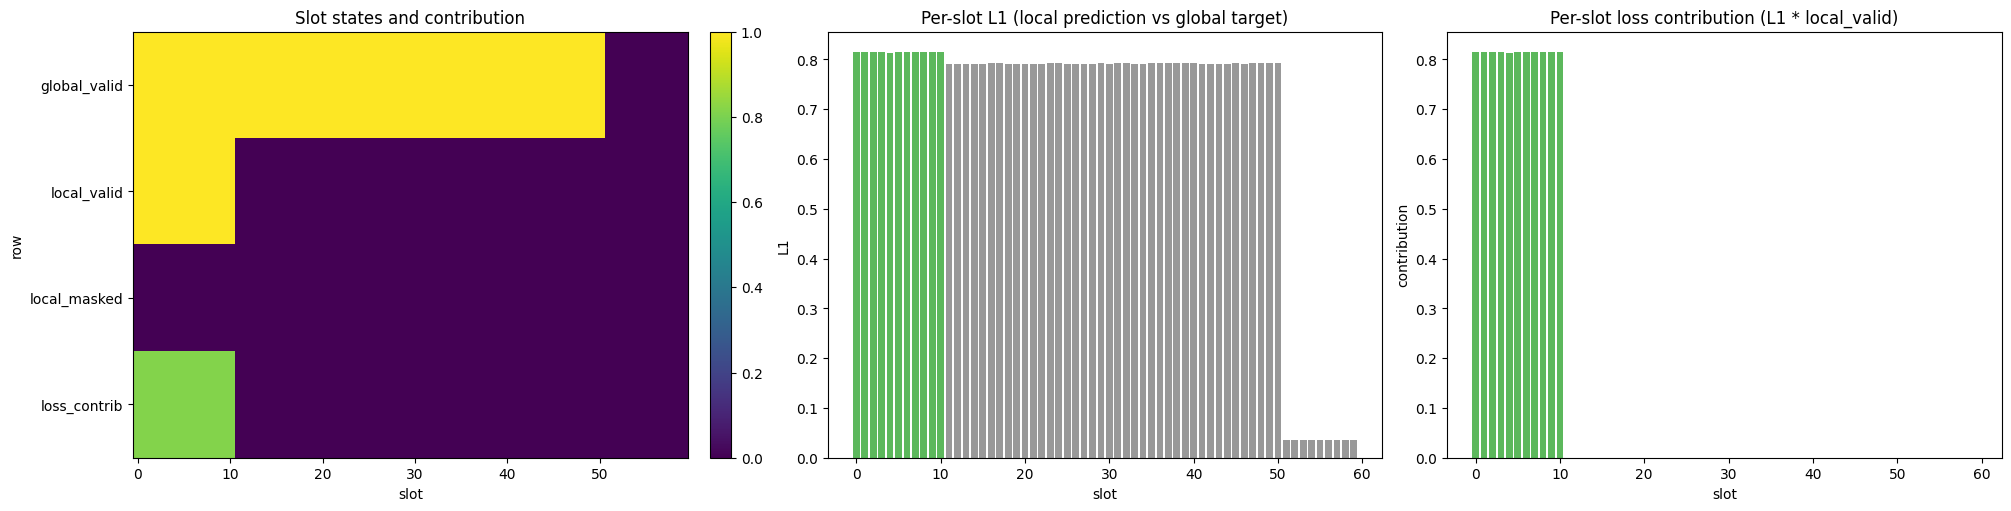

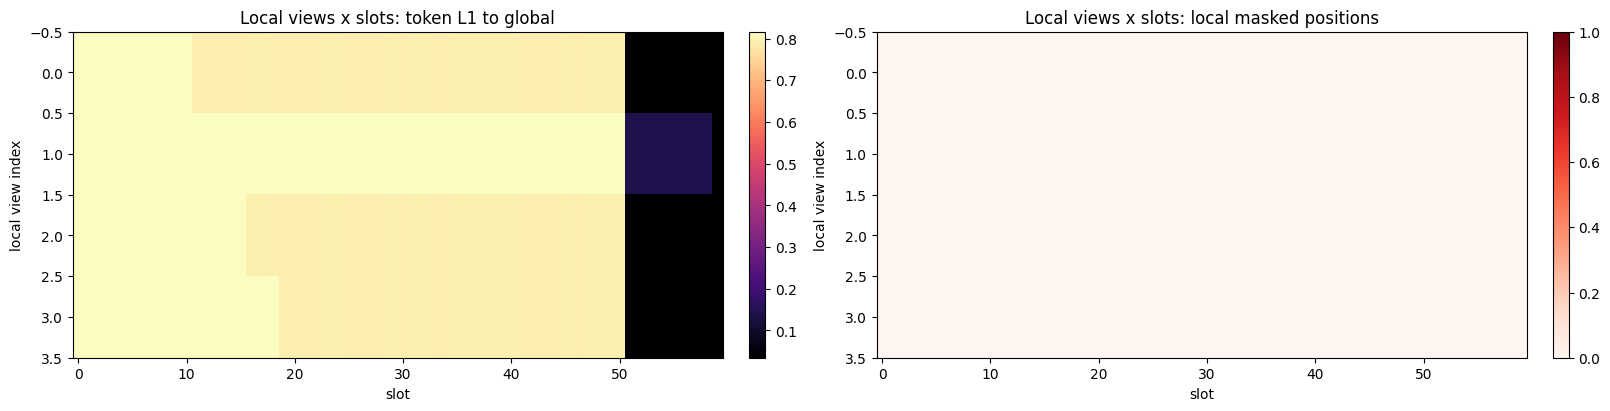

In [14]:
local_plot_idx = 1  # first local view
local_plot_offset = local_plot_idx - 1

local_l1 = per_token_l1_by_local_view[local_plot_offset].detach().cpu().numpy()
local_valid_np = token_valid[local_plot_idx].detach().cpu().numpy().astype(bool)
local_masked_np = token_masked[local_plot_idx].detach().cpu().numpy().astype(bool)

masked_l1 = local_l1[local_masked_np & local_valid_np]
unmasked_l1 = local_l1[(~local_masked_np) & local_valid_np]

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.hist(
    unmasked_l1,
    bins=40,
    alpha=0.7,
    label="local unmasked valid tokens",
    color="#5cb85c",
)
ax.hist(masked_l1, bins=40, alpha=0.7, label="local masked tokens", color="#d9534f")
ax.set_title("Local->Global Predictor L1 by Token Type")
ax.set_xlabel("L1 distance per token")
ax.set_ylabel("count")
ax.legend()

plt.savefig("notebooks/fig_dataflow_stage4_local_global_l1.png", bbox_inches="tight")
plt.show()

print("mean L1 (masked local tokens):", float(masked_l1.mean()))
print("mean L1 (unmasked local tokens):", float(unmasked_l1.mean()))

# --- Extra visualization: slot correspondence local -> global -> mask -> loss ---
sample_b = 0
local_idx = local_plot_idx

local_l1_b = (
    per_token_l1_by_local_view[local_plot_offset][sample_b].detach().cpu().numpy()
)
global_valid_b = token_valid[0, sample_b].detach().cpu().numpy().astype(bool)
local_valid_b = token_valid[local_idx, sample_b].detach().cpu().numpy().astype(bool)
local_masked_b = token_masked[local_idx, sample_b].detach().cpu().numpy().astype(bool)

slot_ids = np.arange(local_l1_b.shape[0])
loss_contrib_b = local_l1_b * local_valid_b.astype(float)
contrib_total = max(loss_contrib_b.sum(), 1e-12)
contrib_pct = loss_contrib_b / contrib_total

slot_df = pd.DataFrame(
    {
        "slot": slot_ids,
        "global_valid": global_valid_b,
        "local_valid": local_valid_b,
        "local_masked": local_masked_b,
        "latent_remasked": local_masked_b,
        "token_l1_local_to_global": local_l1_b,
        "loss_contribution": loss_contrib_b,
        "loss_contribution_pct": contrib_pct,
    }
)

print("Slot correspondence table (sample_b=0, first local view):")
print(slot_df.to_string(index=False))

row_stack = np.vstack(
    [
        global_valid_b.astype(float),
        local_valid_b.astype(float),
        local_masked_b.astype(float),
        loss_contrib_b,
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

im0 = axes[0].imshow(row_stack, aspect="auto", cmap="viridis")
axes[0].set_title("Slot states and contribution")
axes[0].set_xlabel("slot")
axes[0].set_ylabel("row")
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(["global_valid", "local_valid", "local_masked", "loss_contrib"])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

bar_colors = np.where(local_masked_b, "#d9534f", "#5cb85c")
bar_colors = np.where(local_valid_b, bar_colors, "#999999")
axes[1].bar(slot_ids, local_l1_b, color=bar_colors)
axes[1].set_title("Per-slot L1 (local prediction vs global target)")
axes[1].set_xlabel("slot")
axes[1].set_ylabel("L1")

axes[2].bar(slot_ids, loss_contrib_b, color=bar_colors)
axes[2].set_title("Per-slot loss contribution (L1 * local_valid)")
axes[2].set_xlabel("slot")
axes[2].set_ylabel("contribution")

plt.savefig(
    "notebooks/fig_dataflow_stage4_slot_correspondence_loss.png", bbox_inches="tight"
)
plt.show()

# Local-view x slot loss heatmap for the same sample
if len(per_token_l1_by_local_view) > 0:
    local_l1_heat = np.stack(
        [t[sample_b].detach().cpu().numpy() for t in per_token_l1_by_local_view], axis=0
    )
    local_mask_heat = np.stack(
        [
            token_masked[1 + i, sample_b].detach().cpu().numpy().astype(float)
            for i in range(len(per_token_l1_by_local_view))
        ],
        axis=0,
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True)
    im1 = axes[0].imshow(local_l1_heat, aspect="auto", cmap="magma")
    axes[0].set_title("Local views x slots: token L1 to global")
    axes[0].set_xlabel("slot")
    axes[0].set_ylabel("local view index")
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    im2 = axes[1].imshow(local_mask_heat, aspect="auto", cmap="Reds", vmin=0, vmax=1)
    axes[1].set_title("Local views x slots: local masked positions")
    axes[1].set_xlabel("slot")
    axes[1].set_ylabel("local view index")
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    plt.savefig(
        "notebooks/fig_dataflow_stage4_local_views_slot_loss_heatmap.png",
        bbox_inches="tight",
    )
    plt.show()

## Stage 5: Mask-Token Contamination Check (Isolation vs Bidirectional)

**What this stage shows**
- Perturbing `mask_token` and measuring output shifts at masked/unmasked slots.
- Diagram: `fig_dataflow_stage5_mask_token_contamination.png`.

**How to read the diagram**
- Lower is better for `iso/unmasked` (masked token should not leak to unmasked queries).
- `bidir/unmasked` should be larger than `iso/unmasked` by design.


In [15]:
def unmasked_output_shift_when_mask_token_perturbed(model_obj, batch_dict):
    fused_mz = batch_dict["fused_mz"]
    fused_intensity = batch_dict["fused_intensity"]
    fused_valid = batch_dict["fused_valid_mask"]
    fused_prec = batch_dict["fused_precursor_mz"]
    fused_masked = batch_dict["fused_masked_positions"] & fused_valid

    student_intensity = fused_intensity.masked_fill(fused_masked, 0.0)

    with torch.no_grad():
        out_before = model_obj.encoder(
            fused_mz,
            student_intensity,
            valid_mask=fused_valid,
            precursor_mz=fused_prec,
            masked_positions=fused_masked,
            mask_token=model_obj.mask_token,
        )
        saved = model_obj.mask_token.detach().clone()
        model_obj.mask_token.data.add_(5.0)
        out_after = model_obj.encoder(
            fused_mz,
            student_intensity,
            valid_mask=fused_valid,
            precursor_mz=fused_prec,
            masked_positions=fused_masked,
            mask_token=model_obj.mask_token,
        )
        model_obj.mask_token.data.copy_(saved)

    unmasked = ~fused_masked
    masked = fused_masked
    unmasked_diff = (out_before[unmasked] - out_after[unmasked]).abs().mean().item()
    masked_diff = (out_before[masked] - out_after[masked]).abs().mean().item()
    return unmasked_diff, masked_diff


iso_unmasked_diff, iso_masked_diff = unmasked_output_shift_when_mask_token_perturbed(
    model, small_batch
)
bi_unmasked_diff, bi_masked_diff = unmasked_output_shift_when_mask_token_perturbed(
    model_bidir, small_batch
)

print(
    "Isolation mode  | unmasked shift:",
    iso_unmasked_diff,
    "| masked shift:",
    iso_masked_diff,
)
print(
    "Bidirectional   | unmasked shift:",
    bi_unmasked_diff,
    "| masked shift:",
    bi_masked_diff,
)

Isolation mode  | unmasked shift: 0.0 | masked shift: nan
Bidirectional   | unmasked shift: 0.0 | masked shift: nan


/tmp/ipykernel_2828235/2637777776.py:9: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


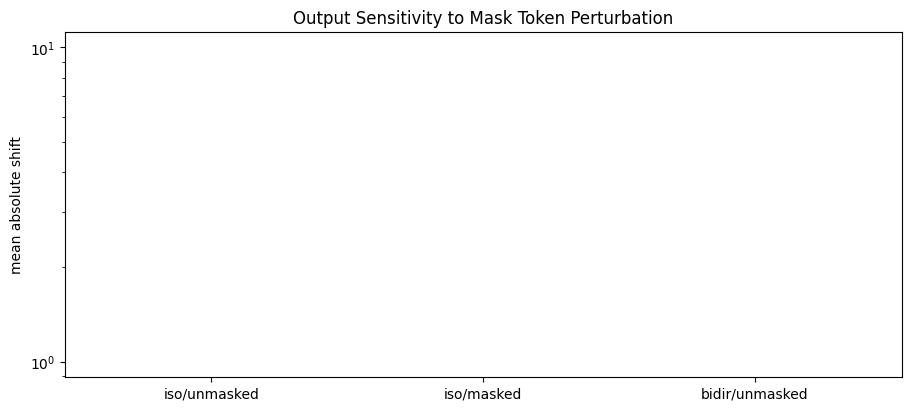

In [16]:
labels = ["iso/unmasked", "iso/masked", "bidir/unmasked", "bidir/masked"]
vals = [iso_unmasked_diff, iso_masked_diff, bi_unmasked_diff, bi_masked_diff]
colors = ["#5bc0de", "#d9534f", "#5bc0de", "#d9534f"]

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.bar(labels, vals, color=colors)
ax.set_title("Output Sensitivity to Mask Token Perturbation")
ax.set_ylabel("mean absolute shift")
ax.set_yscale("log")

plt.savefig(
    "notebooks/fig_dataflow_stage5_mask_token_contamination.png", bbox_inches="tight"
)
plt.show()

## Stage 6: One Non-Compiled Training Step

**What this stage shows**
- Single step metrics under the same objective used in training loop.
- Parameter update norms for key tensors to catch non-finite updates early.

**How to read the output**
- `loss`, `local_global_l1_loss`, `token_sigreg_loss` should all be finite.
- Update norms should be finite and non-zero when corresponding branch is active.


In [17]:
model_train = build_model_from_config(cfg).to(device)
model_train.train()

autocast_dtype = _resolve_autocast_dtype(cfg)
optimizers, schedulers = _build_optimizers(
    cfg,
    model_train,
    total_steps=20,
    device=device,
)

step_batch = {}
for k, v in small_batch.items():
    if isinstance(v, torch.Tensor):
        step_batch[k] = v.clone().detach()
    else:
        step_batch[k] = v

tracked = {
    "mask_token": model_train.mask_token.detach().clone(),
    "predictor_out_w": model_train.masked_latent_predictor[-1].weight.detach().clone(),
    "embedder_w0": model_train.encoder.embedder.mlp[0].weight.detach().clone(),
}

grad_clip_norm = cfg.get("grad_clip_norm", None)
if grad_clip_norm is not None:
    grad_clip_norm = float(grad_clip_norm)

metrics_step = _train_step_impl(
    model_train,
    step_batch,
    optimizers,
    schedulers,
    autocast_dtype,
    grad_clip_norm,
)

updates = {
    "mask_token_update_l2": float(
        (model_train.mask_token.detach() - tracked["mask_token"])
        .pow(2)
        .sum()
        .sqrt()
        .item()
    ),
    "predictor_out_w_update_l2": float(
        (
            model_train.masked_latent_predictor[-1].weight.detach()
            - tracked["predictor_out_w"]
        )
        .pow(2)
        .sum()
        .sqrt()
        .item()
    ),
    "embedder_w0_update_l2": float(
        (model_train.encoder.embedder.mlp[0].weight.detach() - tracked["embedder_w0"])
        .pow(2)
        .sum()
        .sqrt()
        .item()
    ),
}

step_metrics_print = {
    k: float(v.detach().cpu().item())
    for k, v in metrics_step.items()
    if torch.is_tensor(v)
}

print("Step metrics:")
for k in sorted(step_metrics_print):
    print(f"  {k}: {step_metrics_print[k]:.6f}")

print("\nTracked parameter update norms:")
for k, v in updates.items():
    print(f"  {k}: {v:.6e}")

Step metrics:
  alignment: -0.025810
  encoder_pooled_raw_rms: 0.416634
  encoder_pooled_rms: 0.999971
  encoder_variance: 0.031005
  encoder_variance_raw: 0.005643
  local_global_l1_loss: 0.663837
  loss: 164.159210
  masked_fraction: 0.000000
  pool_norm_weight_abs_mean: 1.000000
  representation_variance: 0.109267
  sigreg_loss: 1634.953735
  token_sigreg_loss: 1634.953735
  uniformity: 0.161734
  valid_fraction: 0.692500

Tracked parameter update norms:
  mask_token_update_l2: 0.000000e+00
  predictor_out_w_update_l2: 2.076319e-03
  embedder_w0_update_l2: 1.197585e-03


## Stage 7: Consolidated Audit Summary

**What this stage shows**
- Boolean pass/fail checks for invariants and manual-vs-model consistency.

**How to read the summary table**
- Any `False` indicates either an implementation mismatch or an audit computation mismatch that
  requires investigation before trusting this objective/dataflow path.


In [18]:
summary = {
    "masked_subset_of_valid": checks["masked_subset_of_valid"],
    "masked_positions_not_compacted": checks["masked_positions_not_compacted"],
    "masked_positions_present": checks["masked_positions_present"],
    "attention_block_pattern_exact": bool(
        np.array_equal(blocked_edges, expected_block)
    ),
    "manual_vs_model_local_global_l1_close": float(
        (manual_local_global_l1_loss - metrics["local_global_l1_loss"]).abs().item()
    )
    < 1e-6,
    "manual_vs_model_token_sigreg_close": float(
        (manual_token_sigreg_loss - metrics["token_sigreg_loss"]).abs().item()
    )
    < 1e-6,
    "manual_vs_model_total_loss_close": float(
        (manual_total_loss - metrics["loss"]).abs().item()
    )
    < 1e-6,
    "local_l1_uses_all_valid_not_only_masked": float(
        (manual_local_global_l1_loss - manual_local_global_l1_masked_only).abs().item()
    )
    > 1e-6,
    "iso_mode_unmasked_contamination_low": iso_unmasked_diff < 1e-6,
    "bidir_mode_unmasked_contamination_higher_than_iso": bi_unmasked_diff
    > iso_unmasked_diff,
    "token_sigreg_finite": np.isfinite(float(metrics["token_sigreg_loss"])),
    "train_step_loss_finite": np.isfinite(step_metrics_print["loss"]),
}

summary_df = pd.DataFrame(
    {
        "check": list(summary.keys()),
        "pass": list(summary.values()),
    }
)

print(summary_df.to_string(index=False))

                                            check  pass
                           masked_subset_of_valid  True
                   masked_positions_not_compacted  True
                         masked_positions_present  True
                    attention_block_pattern_exact  True
            manual_vs_model_local_global_l1_close  True
               manual_vs_model_token_sigreg_close  True
                 manual_vs_model_total_loss_close  True
          local_l1_uses_all_valid_not_only_masked  True
              iso_mode_unmasked_contamination_low  True
bidir_mode_unmasked_contamination_higher_than_iso False
                              token_sigreg_finite  True
                           train_step_loss_finite  True
